C:\Users\ASUS\AppData\Local\Temp\ipykernel_268\857582085.py:21: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = X.select_dtypes(include=['object']).columns.tolist()


ROC AUC Score: 0.8863

Confusion Matrix:
[[7800  185]
 [ 729  329]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94      7985
           1       0.64      0.31      0.42      1058

    accuracy                           0.90      9043
   macro avg       0.78      0.64      0.68      9043
weighted avg       0.88      0.90      0.88      9043


Top Positive Influencers:
               Feature  Coefficient  Odds_Ratio
27    poutcome_success     2.351031   10.496390
2             duration     1.053819    2.868587
12         job_student     0.499251    1.647487
9          job_retired     0.422288    1.525448
19  education_tertiary     0.370805    1.448901

Top Negative Influencers:
             Feature  Coefficient  Odds_Ratio
6   job_entrepreneur    -0.476816    0.620757
23          loan_yes    -0.564641    0.568564
7      job_housemaid    -0.611630    0.542466
22       housing_yes    -0.755424    0.469811
25   cont

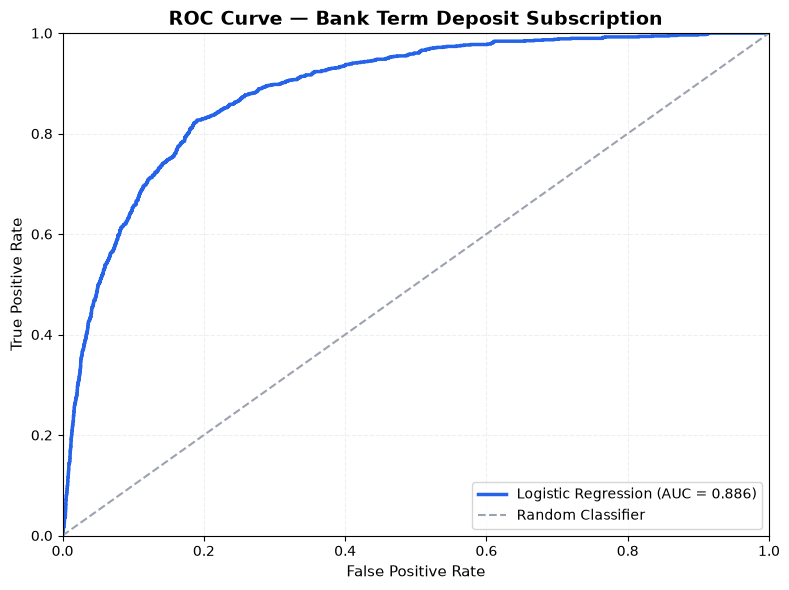

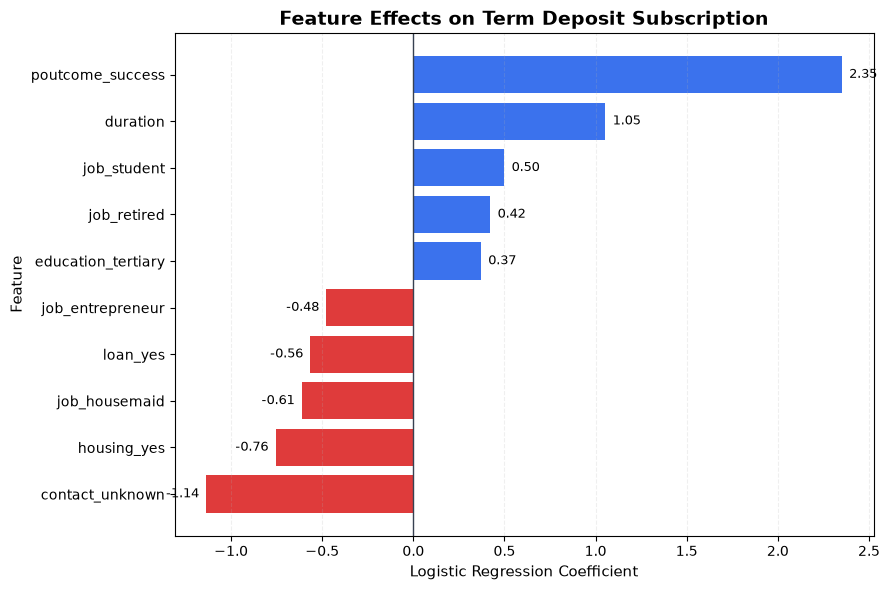

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# 1. Load Dataset
df = pd.read_csv(r"D:\Project\Logistic Regression_Bank Marketing Term Deposit Subscription Prediction\bank_marketing.csv")

# 2. Encode Target Variable
df['target'] = df['subscribed'].map({'yes': 1, 'no': 0})
X = df.drop(columns=['subscribed', 'target'])
y = df['target']

# 3. Identify Feature Types
num_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = X.select_dtypes(include=['object']).columns.tolist()

# 4. Construct Preprocessing Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_features)
    ]
)

# 5. Train-Test Split (80/20 Stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 6. Build and Fit Logistic Regression Pipeline
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

model.fit(X_train, y_train)

# 7. Model Evaluation
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

auc_score = roc_auc_score(y_test, y_pred_proba)
cm = confusion_matrix(y_test, y_pred)

print(f"ROC AUC Score: {auc_score:.4f}")
print("\nConfusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 8. Feature Importance / Coefficients Analysis
ohe = model.named_steps['preprocessor'].named_transformers_['cat']
cat_feature_names = ohe.get_feature_names_out(cat_features).tolist()
all_feature_names = num_features + cat_feature_names

coefs = model.named_steps['classifier'].coef_[0]
importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Coefficient': coefs,
    'Odds_Ratio': np.exp(coefs)
}).sort_values(by='Coefficient', ascending=False)

print("\nTop Positive Influencers:")
print(importance_df.head(5))

print("\nTop Negative Influencers:")
print(importance_df.tail(5))

# ============================================
# ROC Curve
# ============================================

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

# Create figure
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    color="#2563EB",
    linewidth=2.5,
    label=f"Logistic Regression (AUC = {auc_score:.3f})"
)

# Random classifier
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="#9CA3AF",
    linewidth=1.5,
    label="Random Classifier"
)

plt.xlabel("False Positive Rate", fontsize=11)
plt.ylabel("True Positive Rate", fontsize=11)

plt.title(
    "ROC Curve — Bank Term Deposit Subscription",
    fontsize=14,
    fontweight="bold"
)

plt.legend(
    loc="lower right",
    frameon=True
)

plt.grid(
    alpha=0.2,
    linestyle="--"
)

plt.xlim(0, 1)
plt.ylim(0, 1)

plt.tight_layout()

plt.savefig(
    "roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================
# Logistic Regression Feature Effects
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Extract coefficients
coefs = model.named_steps["classifier"].coef_[0]

# Get transformed feature names
ohe = model.named_steps["preprocessor"].named_transformers_["cat"]

cat_feature_names = ohe.get_feature_names_out(
    cat_features
).tolist()

all_feature_names = num_features + cat_feature_names

# Create feature-effects dataframe
feature_effects = pd.DataFrame({
    "Feature": all_feature_names,
    "Coefficient": coefs,
    "Odds_Ratio": np.exp(coefs)
})

# Select strongest positive and negative effects
positive = (
    feature_effects
    .sort_values("Coefficient", ascending=False)
    .head(5)
)

negative = (
    feature_effects
    .sort_values("Coefficient", ascending=True)
    .head(5)
)

# Combine
plot_df = pd.concat(
    [negative, positive]
).sort_values("Coefficient")

# Colors
colors = [
    "#DC2626" if x < 0 else "#2563EB"
    for x in plot_df["Coefficient"]
]

# Plot
fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.barh(
    plot_df["Feature"],
    plot_df["Coefficient"],
    color=colors,
    alpha=0.9
)

# Zero reference line
ax.axvline(
    0,
    color="#374151",
    linewidth=1
)

# Labels
ax.set_xlabel(
    "Logistic Regression Coefficient",
    fontsize=11
)

ax.set_ylabel("Feature", fontsize=11)

ax.set_title(
    "Feature Effects on Term Deposit Subscription",
    fontsize=14,
    fontweight="bold"
)

# Add coefficient labels
for bar, value in zip(
    bars,
    plot_df["Coefficient"]
):
    if value >= 0:
        ax.text(
            value + 0.04,
            bar.get_y() + bar.get_height() / 2,
            f"{value:.2f}",
            va="center",
            fontsize=9
        )
    else:
        ax.text(
            value - 0.04,
            bar.get_y() + bar.get_height() / 2,
            f"{value:.2f}",
            va="center",
            ha="right",
            fontsize=9
        )

ax.grid(
    axis="x",
    alpha=0.2,
    linestyle="--"
)

plt.tight_layout()

plt.savefig(
    "feature_effects.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()